In [54]:
import math
import torch

In [55]:
tensor = torch.tensor([1, 2, 3])
tensor.shape
print(tensor)  # Output: torch.Size([3])

tensor([1, 2, 3])


**Setter opp ligningene

In [ ]:
#m*x''(t)+c*x'(t)+k*x(t) = 0

m,c,k = 0.5, 0.1, 2.0  # mass, damping coefficient, spring constant
T_final = 10  # end of the training time window; t = 0 -> T_final
n_points = 10000  # number of collocation points

class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = torch.nn.Linear(1, 100)
        self.hidden1 = torch.nn.Linear(100, 100)
        self.hidden2 = torch.nn.Linear(100, 100)
        self.output = torch.nn.Linear(100, 1)

    def forward(self, x):
        x = torch.nn.functional.tanh(self.input(x))
        x = torch.nn.functional.tanh(self.hidden1(x))
        x = torch.nn.functional.tanh(self.hidden2(x))
        x = self.output(x)
        return x

In [57]:
def points(t, n_points):
    return torch.linspace(0, 1, steps=n_points).unsqueeze(1) * t


In [58]:
def make_loss_fn(model, m, c, k, w_ic = 1.0, w_physical = 1.0):
    def loss_fn(): 
        t = points(T_final, n_points)
        t.requires_grad = True
        x = model(t)
        x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        residual = m * torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x), create_graph=True)[0] + c*x_t + k*x
        physical_loss = torch.mean(residual**2)

        t0 = torch.tensor([[0.0]], requires_grad=True)
        model_t0 = model(t0)
        ic = torch.mean((model_t0 - 1.0)**2) + torch.mean((torch.autograd.grad(model_t0, t0, grad_outputs=torch.ones_like(t0), create_graph=True)[0] - 0.0)**2)
        loss = {'physical': w_physical * physical_loss, 
                'initial': w_ic * ic
                }
        return loss
    return loss_fn


In [ ]:
def train(model, loss_fn: callable, epochs=1000, LR=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []
    for epoch in range(epochs):
        optimizer.zero_grad() 
        # Compute the loss based on the differential equation
        parts = loss_fn()
        loss = sum(parts.values())
        loss.backward()
        optimizer.step()
        record = {'epoch': epoch, 'total': loss.item()}
        record.update({key: value.item() for key, value in parts.items()})
        history.append(record)
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    return history

In [ ]:
mass_model = Net()

loss = make_loss_fn(mass_model, m, c, k, w_physical=2, w_ic=1.0)

history = train(mass_model, loss, epochs=10000, LR=0.001)  

Epoch 0, Loss: 1.045837163925171
Epoch 100, Loss: 0.11964396387338638
Epoch 200, Loss: 0.09039650857448578
Epoch 300, Loss: 0.07360102236270905
Epoch 400, Loss: 0.0674118846654892
Epoch 500, Loss: 0.06565245985984802
Epoch 600, Loss: 0.07191729545593262
Epoch 700, Loss: 0.06328029185533524
Epoch 800, Loss: 0.062088530510663986
Epoch 900, Loss: 0.06144207343459129
Epoch 1000, Loss: 0.06021317467093468
Epoch 1100, Loss: 0.05896632373332977
Epoch 1200, Loss: 0.058447256684303284
Epoch 1300, Loss: 0.05714918673038483
Epoch 1400, Loss: 0.056032855063676834
Epoch 1500, Loss: 0.05641850456595421
Epoch 1600, Loss: 0.054939739406108856
Epoch 1700, Loss: 0.05392684414982796
Epoch 1800, Loss: 0.05274443328380585
Epoch 1900, Loss: 0.0569225512444973
Epoch 2000, Loss: 0.050479739904403687
Epoch 2100, Loss: 0.047155093401670456
Epoch 2200, Loss: 0.043079476803541183
Epoch 2300, Loss: 0.04054758697748184
Epoch 2400, Loss: 0.041133180260658264
Epoch 2500, Loss: 0.0357811339199543
Epoch 2600, Loss: 0.0

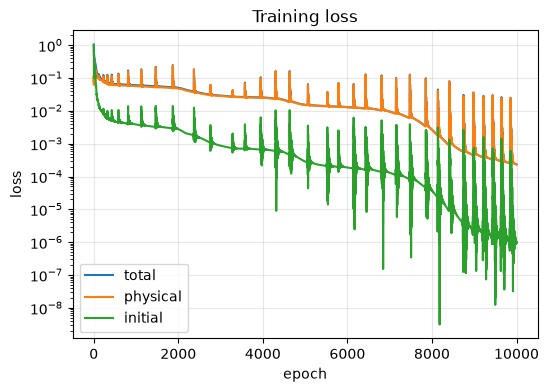

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
epochs_axis = [h['epoch'] for h in history]
for key in ['total', 'physical', 'initial']:
    plt.semilogy(epochs_axis, [h[key] for h in history], label=key)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

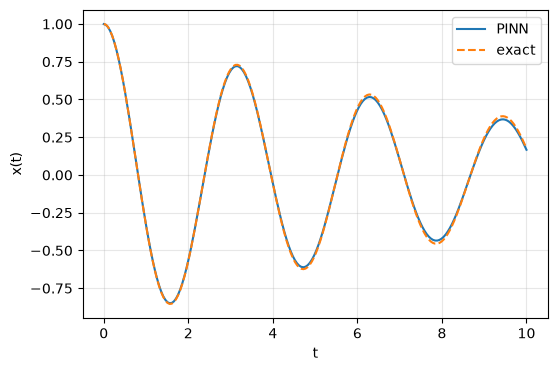

Relative L2 error vs. analytic solution: 2.153e-02


In [62]:
import matplotlib.pyplot as plt

t_plot = torch.linspace(0, T_final, steps=200).unsqueeze(1)
with torch.no_grad():
    x_pred = mass_model(t_plot)

# Closed-form solution of m*x'' + c*x' + k*x = 0, x(0)=1, x'(0)=0 (underdamped case)
zeta = c / (2 * math.sqrt(m * k))
wn = math.sqrt(k / m)
wd = wn * math.sqrt(1 - zeta**2)
A = 1.0
B = zeta * wn * A / wd
x_exact = torch.exp(-zeta * wn * t_plot) * (A * torch.cos(wd * t_plot) + B * torch.sin(wd * t_plot))

plt.figure(figsize=(6, 4))
plt.plot(t_plot.numpy(), x_pred.numpy(), label="PINN")
plt.plot(t_plot.numpy(), x_exact.numpy(), "--", label="exact")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

rel_l2 = (torch.linalg.norm(x_pred - x_exact) / torch.linalg.norm(x_exact)).item()
print(f"Relative L2 error vs. analytic solution: {rel_l2:.3e}")